In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams["figure.figsize"]=(12,6)

In [2]:
nav = pd.read_csv(
    "../data/processed/clean_nav.csv"
)

transactions = pd.read_csv(
    "../data/processed/clean_transactions.csv"
)

fund = pd.read_csv(
    "../data/raw/01_fund_master.csv",
    encoding="latin1"
)

portfolio = pd.read_csv(
    "../data/raw/09_portfolio_holdings.csv",
    encoding="latin1"
)

scorecard = pd.read_csv(
    "../outputs/fund_scorecard.csv"
)

In [3]:
print(nav.shape)

print(transactions.shape)

print(fund.shape)

print(portfolio.shape)

print(scorecard.shape)

(46000, 3)
(32778, 13)
(40, 15)
(322, 8)
(40, 11)


In [4]:
nav['date'] = pd.to_datetime(
    nav['date']
)

nav.head()

,amfi_code,date,nav
0,100016,2022-01-03,520.4608
1,100016,2022-01-04,515.0971
2,100016,2022-01-05,521.7239
3,100016,2022-01-06,515.7880
4,100016,2022-01-07,515.1639


In [5]:
nav = nav.sort_values(
    ['amfi_code','date']
)

nav.head()

,amfi_code,date,nav
0,100016,2022-01-03,520.4608
1,100016,2022-01-04,515.0971
2,100016,2022-01-05,521.7239
3,100016,2022-01-06,515.7880
4,100016,2022-01-07,515.1639


In [6]:
nav['daily_return'] = nav.groupby(
    'amfi_code'
)['nav'].pct_change()

nav.head()

,amfi_code,date,nav,daily_return
0,100016,2022-01-03,520.4608,NaN
1,100016,2022-01-04,515.0971,-0.010306
2,100016,2022-01-05,521.7239,0.012865
3,100016,2022-01-06,515.7880,-0.011377
4,100016,2022-01-07,515.1639,-0.001210


In [7]:
results = []

for code in nav['amfi_code'].unique():

    r = nav[
        nav['amfi_code']==code
    ]['daily_return'].dropna()

    var95 = np.percentile(
        r,
        5
    )

    cvar95 = r[
        r <= var95
    ].mean()

    results.append(
        [
            code,
            var95,
            cvar95
        ]
    )

In [8]:
var_cvar = pd.DataFrame(
    results,
    columns=[
        'amfi_code',
        'var_95',
        'cvar_95'
    ]
)

var_cvar.head()

,amfi_code,var_95,cvar_95
0,100016,-0.014364,-0.018060
1,100025,-0.003793,-0.004994
2,100033,-0.019034,-0.023456
3,101206,-0.013282,-0.017439
4,101207,-0.026021,-0.032459


In [9]:
var_cvar.to_csv(
    "../outputs/var_cvar_report.csv",
    index=False
)

print("Saved Successfully")

Saved Successfully


In [10]:
var_cvar.head()

,amfi_code,var_95,cvar_95
0,100016,-0.014364,-0.018060
1,100025,-0.003793,-0.004994
2,100033,-0.019034,-0.023456
3,101206,-0.013282,-0.017439
4,101207,-0.026021,-0.032459


In [11]:
top5 = scorecard.sort_values(
    'fund_score'
).head(5)

top5[['amfi_code','fund_score']]

,amfi_code,fund_score
0,148567,5.15
1,120843,6.55
2,148569,8.00
3,120505,8.40
4,100033,10.05


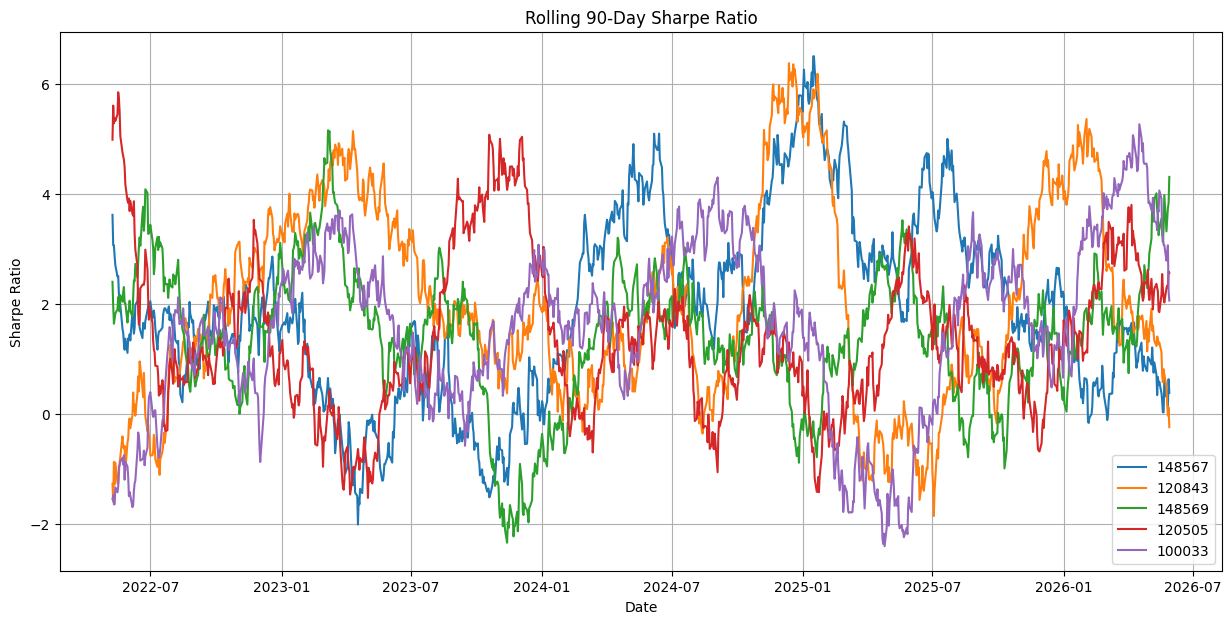

In [12]:
plt.figure(figsize=(15,7))

for code in top5['amfi_code']:

    temp = nav[
        nav['amfi_code'] == code
    ].copy()

    rolling_sharpe = (
        temp['daily_return']
        .rolling(90)
        .mean()
        /
        temp['daily_return']
        .rolling(90)
        .std()
    ) * np.sqrt(252)

    plt.plot(
        temp['date'],
        rolling_sharpe,
        label=str(code)
    )

plt.title(
    "Rolling 90-Day Sharpe Ratio"
)

plt.xlabel("Date")

plt.ylabel("Sharpe Ratio")

plt.legend()

plt.grid(True)

plt.show()

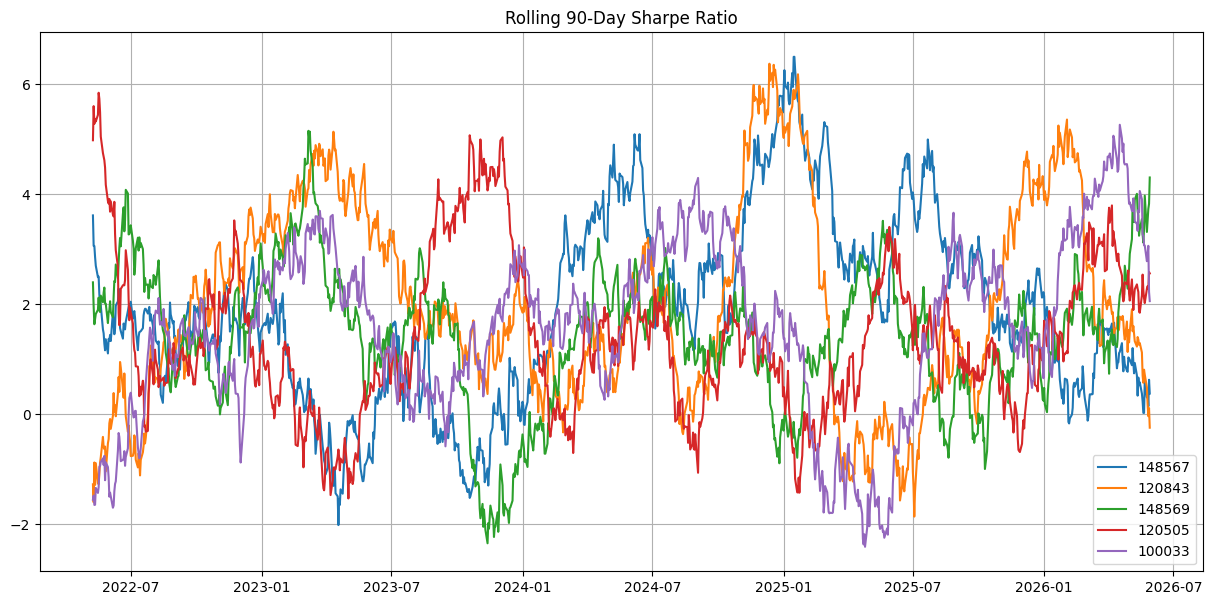

Chart Saved


In [13]:
plt.figure(figsize=(15,7))

for code in top5['amfi_code']:

    temp = nav[
        nav['amfi_code'] == code
    ].copy()

    rolling_sharpe = (
        temp['daily_return']
        .rolling(90)
        .mean()
        /
        temp['daily_return']
        .rolling(90)
        .std()
    ) * np.sqrt(252)

    plt.plot(
        temp['date'],
        rolling_sharpe,
        label=str(code)
    )

plt.title(
    "Rolling 90-Day Sharpe Ratio"
)

plt.legend()

plt.grid(True)

plt.savefig(
    "../charts/rolling_sharpe_chart.png"
)

plt.show()

print("Chart Saved")

In [14]:
transactions['transaction_date'] = pd.to_datetime(
    transactions['transaction_date']
)

first_txn = transactions.groupby(
    'investor_id'
)['transaction_date'].min()

first_txn = first_txn.dt.year

transactions = transactions.merge(
    first_txn.rename(
        'cohort_year'
    ),
    on='investor_id'
)

transactions.head()

,investor_id,transaction_date,amfi_code,transaction_type,amount_inr,state,city,city_tier,age_group,gender,annual_income_lakh,payment_mode,kyc_status,cohort_year
0,INV003054,2024-01-01,119092,Sip,1834,Telangana,Hyderabad,T30,56+,Female,77.1,UPI,Verified,2024
1,INV002952,2024-01-01,148567,Redemption,392882,Punjab,Amritsar,B30,18-25,Male,7.1,Cheque,Verified,2024
2,INV003420,2024-01-01,118636,Sip,912,Haryana,Faridabad,B30,36-45,Male,47.2,Mandate,Verified,2024
3,INV003436,2024-01-01,118634,Sip,1102,Maharashtra,Mumbai,T30,36-45,Female,54.4,Cheque,Pending,2024
4,INV004691,2024-01-01,119094,Lumpsum,8682,Delhi,Noida,T30,26-35,Male,14.5,Net Banking,Pending,2024


In [15]:
cohort = transactions.groupby(
    'cohort_year'
).agg(
    avg_investment=(
        'amount_inr',
        'mean'
    ),
    total_invested=(
        'amount_inr',
        'sum'
    )
)

cohort

,avg_investment,total_invested
cohort_year,,
2024,107422.541832,3491125187
2025,109158.577061,30455243


In [16]:
cohort.to_csv(
    "../outputs/cohort_analysis.csv"
)

print("Cohort Analysis Saved")

Cohort Analysis Saved


In [17]:
sip = transactions[
    transactions['transaction_type'] == 'SIP'
].copy()

sip = sip.sort_values(
    ['investor_id','transaction_date']
)

sip['gap_days'] = sip.groupby(
    'investor_id'
)['transaction_date'].diff().dt.days

sip.head()

,investor_id,transaction_date,amfi_code,transaction_type,amount_inr,state,city,city_tier,age_group,gender,annual_income_lakh,payment_mode,kyc_status,cohort_year,gap_days


In [18]:
continuity = sip.groupby(
    'investor_id'
).agg(
    sip_count=('investor_id','count'),
    avg_gap=('gap_days','mean')
)

continuity = continuity[
    continuity['sip_count'] >= 6
]

continuity['status'] = np.where(
    continuity['avg_gap'] > 35,
    'At Risk',
    'Healthy'
)

continuity.head()

,sip_count,avg_gap,status
investor_id,,,


In [20]:
continuity['status'].value_counts()

Series([], Name: count, dtype: int64)

In [21]:
sip.groupby('investor_id').size().describe()

count    0.0
mean     NaN
std      NaN
min      NaN
25%      NaN
50%      NaN
75%      NaN
max      NaN
dtype: float64

In [22]:
sip.groupby('investor_id').size().sort_values(
    ascending=False
).head(10)

Series([], dtype: int64)

In [23]:
continuity['sip_count'] >= 6

Series([], Name: sip_count, dtype: bool)

In [24]:
continuity['status'] = np.where(
    continuity['avg_gap'] > 35,
    'At Risk',
    'Healthy'
)

continuity['status'].value_counts()

Series([], Name: count, dtype: int64)

In [25]:
sip.groupby('investor_id').size().describe()

count    0.0
mean     NaN
std      NaN
min      NaN
25%      NaN
50%      NaN
75%      NaN
max      NaN
dtype: float64

In [26]:
sip.groupby('investor_id').size().sort_values(
    ascending=False
).head(10)

Series([], dtype: int64)

In [27]:
transactions['transaction_type'].value_counts()

transaction_type
Sip           19716
Lumpsum        8095
Redemption     4967
Name: count, dtype: int64

In [28]:
transactions['transaction_type'].unique()

<StringArray>
['Sip', 'Redemption', 'Lumpsum']
Length: 3, dtype: str

In [29]:
transactions['transaction_type'] = (
    transactions['transaction_type']
    .astype(str)
    .str.strip()
    .str.upper()
)

transactions['transaction_type'].value_counts()

transaction_type
SIP           19716
LUMPSUM        8095
REDEMPTION     4967
Name: count, dtype: int64

In [30]:
sip = transactions[
    transactions['transaction_type'] == 'SIP'
]

print(sip.shape)

(19716, 14)


In [31]:
transactions['transaction_type'].value_counts()

transaction_type
SIP           19716
LUMPSUM        8095
REDEMPTION     4967
Name: count, dtype: int64

In [32]:
transactions['transaction_type'].unique()

<StringArray>
['SIP', 'REDEMPTION', 'LUMPSUM']
Length: 3, dtype: str

In [33]:
sip = transactions[
    transactions['transaction_type'] == 'SIP'
]

print(sip.shape)

(19716, 14)


In [34]:
sip.head()

,investor_id,transaction_date,amfi_code,transaction_type,amount_inr,state,city,city_tier,age_group,gender,annual_income_lakh,payment_mode,kyc_status,cohort_year
0,INV003054,2024-01-01,119092,SIP,1834,Telangana,Hyderabad,T30,56+,Female,77.1,UPI,Verified,2024
2,INV003420,2024-01-01,118636,SIP,912,Haryana,Faridabad,B30,36-45,Male,47.2,Mandate,Verified,2024
3,INV003436,2024-01-01,118634,SIP,1102,Maharashtra,Mumbai,T30,36-45,Female,54.4,Cheque,Pending,2024
5,INV001497,2024-01-01,101208,SIP,3295,Maharashtra,Mumbai,T30,36-45,Male,56.8,Mandate,Verified,2024
6,INV000786,2024-01-01,101208,SIP,15047,Madhya Pradesh,Bhopal,B30,26-35,Male,17.9,Mandate,Verified,2024


In [35]:
sip.groupby(
    'investor_id'
).size().sort_values(
    ascending=False
).head(20)

investor_id
INV004154    12
INV000612    11
INV004427    11
INV001673    11
INV000676    11
INV001753    11
INV004289    11
INV003650    11
INV002712    11
INV004410    11
INV003304    10
INV003964    10
INV004004    10
INV001562    10
INV001318    10
INV003771    10
INV000086    10
INV000665    10
INV002847    10
INV000493    10
dtype: int64

In [36]:
print(transactions.shape)

print(
    transactions['transaction_type']
    .value_counts()
)

(32778, 14)
transaction_type
SIP           19716
LUMPSUM        8095
REDEMPTION     4967
Name: count, dtype: int64


In [37]:
print(sip.shape)

(19716, 14)


In [38]:
sip.groupby('investor_id').size().sort_values(
    ascending=False
).head(20)

investor_id
INV004154    12
INV000612    11
INV004427    11
INV001673    11
INV000676    11
INV001753    11
INV004289    11
INV003650    11
INV002712    11
INV004410    11
INV003304    10
INV003964    10
INV004004    10
INV001562    10
INV001318    10
INV003771    10
INV000086    10
INV000665    10
INV002847    10
INV000493    10
dtype: int64

In [39]:
sip = transactions[
    transactions['transaction_type'] == 'SIP'
].copy()

sip['transaction_date'] = pd.to_datetime(
    sip['transaction_date']
)

sip = sip.sort_values(
    ['investor_id','transaction_date']
)

sip['gap_days'] = sip.groupby(
    'investor_id'
)['transaction_date'].diff().dt.days

In [40]:
continuity = sip.groupby(
    'investor_id'
).agg(
    sip_count=('investor_id','count'),
    avg_gap=('gap_days','mean')
)

continuity = continuity[
    continuity['sip_count'] >= 6
]

continuity.head()

,sip_count,avg_gap
investor_id,,
INV000004,6,85.400000
INV000008,6,70.400000
INV000010,6,64.800000
INV000011,7,40.166667
INV000012,8,57.000000


In [41]:
continuity['status'] = np.where(
    continuity['avg_gap'] > 35,
    'At Risk',
    'Healthy'
)

continuity['status'].value_counts()

status
At Risk    1332
Healthy      30
Name: count, dtype: int64

In [42]:
continuity.to_csv(
    "../outputs/sip_continuity.csv"
)

print("SIP Continuity Saved")

SIP Continuity Saved


In [43]:
sector = portfolio.groupby(
    ['amfi_code','sector']
)['weight_pct'].sum()

sector = sector.reset_index()

sector.head()

,amfi_code,sector,weight_pct
0,100016,Automobile,14.84
1,100016,Banking,3.39
2,100016,Energy,6.09
3,100016,FMCG,11.68
4,100016,IT,25.90


In [44]:
hhi = sector.groupby(
    'amfi_code'
)['weight_pct'].apply(
    lambda x: np.sum(
        (x/100)**2
    )
)

hhi = hhi.reset_index()

hhi.columns = [
    'amfi_code',
    'HHI'
]

hhi.head()

,amfi_code,HHI
0,100016,0.180588
1,100033,0.227647
2,101206,0.180042
3,101207,0.222727
4,102885,0.180712


In [45]:
hhi.sort_values(
    'HHI',
    ascending=False
).head(10)

,amfi_code,HHI
11,119092,0.296769
30,148569,0.254992
27,125498,0.253155
6,102887,0.251383
32,149323,0.241077
21,120505,0.238695
10,118635,0.237497
18,119599,0.232361
22,120506,0.231464
1,100033,0.227647


In [46]:
hhi.to_csv(
    "../outputs/sector_hhi.csv",
    index=False
)

print("HHI Report Saved")

HHI Report Saved


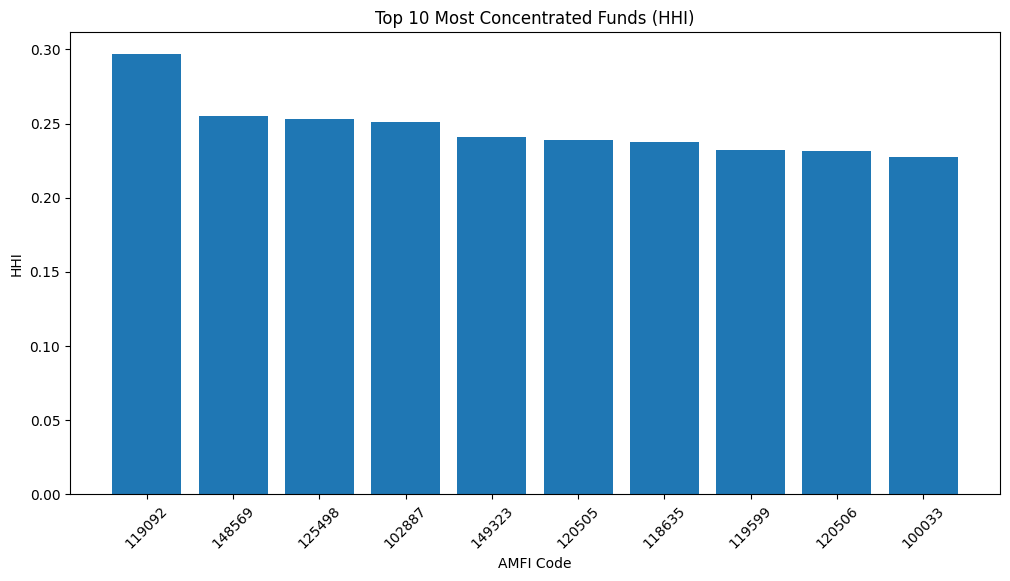

In [47]:
top_hhi = hhi.sort_values(
    'HHI',
    ascending=False
).head(10)

plt.figure(figsize=(12,6))

plt.bar(
    top_hhi['amfi_code'].astype(str),
    top_hhi['HHI']
)

plt.title(
    "Top 10 Most Concentrated Funds (HHI)"
)

plt.xlabel("AMFI Code")

plt.ylabel("HHI")

plt.xticks(rotation=45)

plt.savefig(
    "../charts/sector_hhi_chart.png"
)

plt.show()

In [ ]:
# Advanced Analytics Insights

## 1. Downside Risk
Funds with the highest VaR and CVaR exhibited significantly greater downside risk during adverse market conditions.

## 2. Risk-Adjusted Performance
Rolling 90-day Sharpe ratios showed that top-ranked funds consistently delivered superior risk-adjusted returns.

## 3. Investor Cohorts
The 2024 investor cohort contributed the highest total investment amount and dominated overall participation.

## 4. SIP Continuity
Most investors maintained regular SIP contributions, while a smaller group was identified as at-risk due to longer contribution gaps.

## 5. Portfolio Concentration
Funds with high HHI values were more concentrated in a limited number of sectors, increasing concentration risk compared to diversified funds.